# Rare Object Detection — Embedding Evaluation & Active Learning

This notebook evaluates the quality of learned embeddings across training runs that vary two hyperparameters:
- **Label fraction `f`**: fraction of the training set that carries morphological labels (0 = fully unsupervised, 1 = fully labelled)
- **Supervision weight `sw`**: relative weight of the supervised contrastive loss term

Retrieval quality is measured with **nDCG@10** per morphological class. The second half of the notebook runs **Protege** Gaussian-Process active learning on the resulting embeddings to efficiently surface rare/interesting radio galaxies.

In [7]:
import re
import subprocess
import sys

# Install dependencies only if missing
def _install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

try:
    import astronomaly
except ModuleNotFoundError:
    _install("git+https://github.com/MichelleLochner/astronomaly.git")

try:
    import pyarrow
except ModuleNotFoundError:
    _install("pyarrow", "fastparquet", "numpy<2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pathlib import Path
from scipy.spatial.distance import cdist
import astronomaly
from astronomaly.anomaly_detection import protege, human_loop_learning

print("astronomaly version:", astronomaly.__version__)
print("numpy version:", np.__version__)
print("pyarrow version:", pyarrow.__version__)

%matplotlib inline

astronomaly version: 2.0
numpy version: 1.26.4
pyarrow version: 14.0.2


## Retrieval Metric: nDCG@10

`nDCGk_avg` computes the mean nDCG@10 score for a given morphological class by treating every member of that class as a query in turn, ranking the remaining embeddings by cosine similarity, and scoring the ranked list against ground-truth labels. A score of 1.0 means all top-10 nearest neighbours belong to the correct class; 0.0 means none do.

In [8]:
def get_relevance(proj_in, lab_in, ref_class, mode="uniform"):
    relevance = np.zeros((proj_in.shape[0],))
    relevance[lab_in[:,ref_class]==True] = 1
    return relevance

def DCG(relevance_descending, k=10):
    num = 2**relevance_descending[:k] - 1
    den = np.log2(1+np.arange(1,k+1))
    return (num/den).sum()

def nDCG(relevance, sorting_cossim, k=10):
    IDCGk = DCG(np.sort(relevance)[::-1], k=k)
    DCGk = DCG(relevance[sorting_cossim], k=k)
    return DCGk/IDCGk

def nDCGk_avg(proj_in, lab_in, ref_class, k=20):
    mask_class = (lab_in[:,ref_class]==True)
    res = []
    for idx_ref in range(mask_class.sum()):
        reference_proj = proj_in[(lab_in[:,ref_class]==True)][idx_ref]
        mask_ref = (np.arange(proj_in.shape[0])==np.argwhere((lab_in[:,ref_class]==True))[idx_ref])
        proj_search = proj_in[~mask_ref]
        cos_d  = cdist(reference_proj[None,:], proj_search,   metric='cosine')
        sorting_cossim = np.argsort(cos_d.squeeze())
        relevance = get_relevance(proj_search, lab_in[~mask_ref], ref_class)
        nDCG_samp = nDCG(relevance, sorting_cossim, k=k)
        res.append(nDCG_samp)
    #print(f"processed {idx_ref} ref proj from class {ref_class}")
    return (np.asarray(res).mean())

In [9]:
# ── Part 1 — nDCG Evaluation Config ─────────────────────────────────────────
OUTPUTS_ROOT   = Path("/users/mbredber/p3_SUPLAT/outputs")
RUN_GLOB       = "run_no_val_run_f*_sw*"   # pattern for multi-run scan
SINGLE_RUN_DIR = OUTPUTS_ROOT / "run_no_val_run_f1_sw3_20260521_1641"
EVAL_SPLIT     = "test"    # split used for nDCG evaluation
N_CLASSES      = 20        # number of label dimensions
NDCG_K         = 20        # k in nDCG@k

## Single-Run Baseline

Quick inspection of one training run: loads test-split embeddings and computes nDCG@10 across all 17 morphological classes.

In [10]:
# Extract the run name from the directory path
run_name = SINGLE_RUN_DIR.name

emb_dir = SINGLE_RUN_DIR / "data"
proj    = np.load(emb_dir / f'{EVAL_SPLIT}_projections.npy')
labels  = np.load(emb_dir / f'{EVAL_SPLIT}_labels.npy')

result_w10 = []
for class_id in range(N_CLASSES):
    nDGG10_class = nDCGk_avg(proj, labels, class_id, k=NDCG_K)
    result_w10.append(nDGG10_class)
    print(f"Class: {class_id} | nDCG@{NDCG_K} = {nDGG10_class}")

Class: 0 | nDCG@20 = 0.6051794741084231
Class: 1 | nDCG@20 = 0.8389967195076221
Class: 2 | nDCG@20 = 0.3286121727078525
Class: 3 | nDCG@20 = 0.22525036353590452
Class: 4 | nDCG@20 = 0.32366588966201887
Class: 5 | nDCG@20 = 0.4363749434286777
Class: 6 | nDCG@20 = 0.17110251646792293
Class: 7 | nDCG@20 = 0.2193473200316428
Class: 8 | nDCG@20 = 0.29147535429527716
Class: 9 | nDCG@20 = 0.07367063272686407
Class: 10 | nDCG@20 = 0.31737923712563093
Class: 11 | nDCG@20 = 0.35801562211448507
Class: 12 | nDCG@20 = 0.08654765638378709
Class: 13 | nDCG@20 = 0.026053130374996722
Class: 14 | nDCG@20 = 0.0
Class: 15 | nDCG@20 = 0.05915185854680784
Class: 16 | nDCG@20 = 0.032129469524552534
Class: 17 | nDCG@20 = 0.05923023671754155
Class: 18 | nDCG@20 = 0.1917885148447059
Class: 19 | nDCG@20 = 0.045385629822124914


## Multi-Run Comparison

Loads test embeddings from every `run_no_val_run_f*_sw*` run directory, computes per-class nDCG@10 for each, and collects the results into `run_results` for plotting. Uses `EVAL_SPLIT` rather than `SPLIT` to avoid overwriting the active-learning split variable set later.

In [11]:
run_dirs = sorted(OUTPUTS_ROOT.glob(RUN_GLOB))

run_results = []
for rd in run_dirs:
    m = re.search(r'_f([\d.]+)_sw([\d.]+)_', rd.name)
    if not m:
        continue
    f_val    = float(m.group(1))
    sw_val   = float(m.group(2))
    data_dir = rd / "data"
    proj_path   = data_dir / f"{EVAL_SPLIT}_projections.npy"
    labels_path = data_dir / f"{EVAL_SPLIT}_labels.npy"
    if not proj_path.exists() or not labels_path.exists():
        print(f"  skipping {rd.name}  (missing {EVAL_SPLIT} projection files)")
        continue
    proj   = np.load(proj_path)
    labels = np.load(labels_path)
    ndcg   = [nDCGk_avg(proj, labels, c, k=NDCG_K) for c in range(N_CLASSES)]
    run_results.append(dict(name=rd.name, f=f_val, sw=sw_val, ndcg=ndcg))
    print(f"  loaded {rd.name}  (f={f_val}, sw={sw_val})")

print(f"\nLoaded {len(run_results)} runs.")

  skipping run_no_val_run_f0.2_sw1_20260522_1610  (missing test projection files)
  loaded run_no_val_run_f0.2_sw3_20260521_1836  (f=0.2, sw=3.0)
  loaded run_no_val_run_f0.5_sw3_20260521_1904  (f=0.5, sw=3.0)
  loaded run_no_val_run_f0_sw1_20260521_1517  (f=0.0, sw=1.0)
  loaded run_no_val_run_f1_sw0.5_20260521_1537  (f=1.0, sw=0.5)
  loaded run_no_val_run_f1_sw10_20260521_1833  (f=1.0, sw=10.0)
  loaded run_no_val_run_f1_sw1_20260521_1609  (f=1.0, sw=1.0)
  loaded run_no_val_run_f1_sw3_20260521_1641  (f=1.0, sw=3.0)

Loaded 7 runs.


### nDCG@10 Results Plot

Each point is one (run, class) pair. **Colour** encodes `sw` on a log-scaled viridis gradient (dark = low, bright = high). **Filled fraction of the circle** encodes `f`: an empty circle means no labels were used; a fully filled circle means all labels were used.

Saved: /users/mbredber/p3_SUPLAT/outputs/ndcg_per_class.pdf


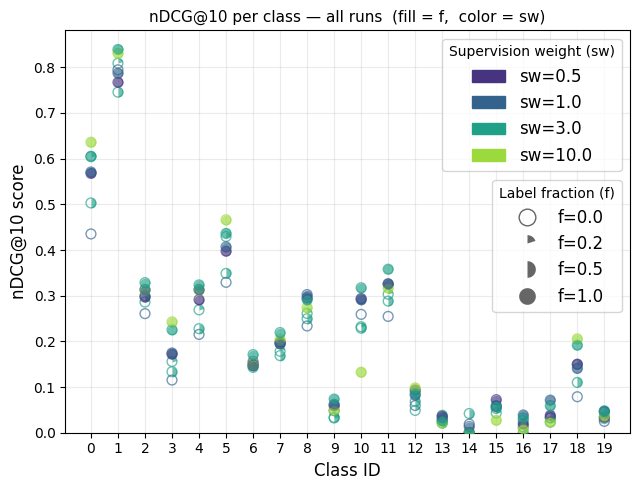

In [12]:
from matplotlib.path import Path as MPath

def pie_marker(fraction):
    """Wedge Path covering `fraction` of the unit circle, clockwise from 12 o'clock."""
    if fraction >= 1.0:
        n = 100
        t = np.linspace(0, 2 * np.pi, n, endpoint=False)
        verts = np.column_stack([np.cos(t), np.sin(t)])
        codes = [MPath.MOVETO] + [MPath.LINETO] * (n - 1) + [MPath.CLOSEPOLY]
        return MPath(np.vstack([verts, verts[:1]]), codes)
    n = 50
    t = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi * fraction, n)
    verts = [(0.0, 0.0)] + list(zip(np.cos(t), np.sin(t))) + [(0.0, 0.0)]
    codes = [MPath.MOVETO] + [MPath.LINETO] * n + [MPath.CLOSEPOLY]
    return MPath(verts, codes)


f_vals  = sorted(set(r['f']  for r in run_results))
sw_vals = sorted(set(r['sw'] for r in run_results))

cmap    = plt.cm.viridis
sw_log  = np.log10(sw_vals)
sw_norm = (sw_log - sw_log.min()) / (sw_log.max() - sw_log.min() + 1e-9)
sw_color = {sw: cmap(0.15 + 0.70 * v) for sw, v in zip(sw_vals, sw_norm)}

fig, ax = plt.subplots(figsize=(6.5, 5))
x = np.arange(N_CLASSES)
S, ALPHA = 50, 0.65

for r in run_results:
    color = sw_color[r['sw']]
    ax.scatter(x, r['ndcg'], facecolors='none', edgecolors=[color] * N_CLASSES,
               marker='o', s=S, linewidths=1.0, zorder=2, alpha=ALPHA)
    if r['f'] > 0:
        ax.scatter(x, r['ndcg'], color=color, marker=pie_marker(r['f']),
                   s=S, linewidths=0, zorder=3, alpha=ALPHA)

ax.set_xlabel("Class ID", fontsize=12)
ax.set_ylabel("nDCG@10 score", fontsize=12)
ax.set_ylim([0, None])
ax.set_xticks(x)
ax.tick_params(labelsize=10)
ax.grid(True, alpha=0.25)

LFS, LMS = 12, 12  # legend fontsize, markersize
grey = (0.4, 0.4, 0.4)

f_handles = []
for f in f_vals:
    if f == 0:
        h = mlines.Line2D([], [], linestyle='None', marker='o', markersize=LMS,
                          markerfacecolor='none', markeredgecolor=grey,
                          markeredgewidth=1.0, label=f'f={f}')
    else:
        h = mlines.Line2D([], [], linestyle='None', marker=pie_marker(f), markersize=LMS,
                          markerfacecolor=grey, markeredgecolor='none', label=f'f={f}')
    f_handles.append(h)

sw_handles = [
    mpatches.Patch(color=sw_color[sw], label=f'sw={sw}')
    for sw in sw_vals
]

# Stack both legends at upper right
leg_sw = ax.legend(handles=sw_handles, title='Supervision weight (sw)',
                   loc='upper right', bbox_to_anchor=(1.0, 1.0),
                   framealpha=0.8, fontsize=LFS)
ax.add_artist(leg_sw)
ax.legend(handles=f_handles, title='Label fraction (f)',
          loc='upper right', bbox_to_anchor=(1.0, 0.65),
          framealpha=0.8, fontsize=LFS)

ax.set_title("nDCG@10 per class — all runs  (fill = f,  color = sw)", fontsize=11)
plt.tight_layout()

_pdf_path = Path(OUTPUTS_ROOT) / "ndcg_per_class.pdf"
fig.savefig(_pdf_path, bbox_inches="tight")
print(f"Saved: {_pdf_path}")

plt.show()

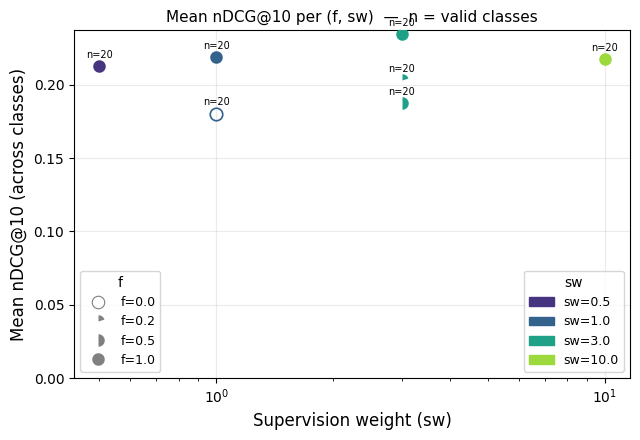

In [64]:
### Average nDCG@10 per (f, sw) combination

fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Group by f so runs with the same f get connected
runs_by_f = {}
for r in run_results:
    runs_by_f.setdefault(r['f'], []).append(r)

for f_val in sorted(runs_by_f):
    group = sorted(runs_by_f[f_val], key=lambda r: r['sw'])
    marker = pie_marker(f_val) if f_val > 0 else 'o'
    mfc = 'none' if f_val == 0 else None  # filled for f>0 (color set per point), empty circle for f=0

    for r in group:
        x = r['sw']
        y = np.nanmean(r['ndcg'])
        n = int(np.sum(~np.isnan(r['ndcg'])))
        c = sw_color[r['sw']]
        mkw = dict(markerfacecolor='none', markeredgecolor=c, markeredgewidth=1.2) if f_val == 0 \
              else dict(markerfacecolor=c, markeredgecolor='none')
        ax.plot(x, y, marker=marker, markersize=9, linestyle='none', zorder=3, **mkw)
        ax.annotate(f'n={n}', xy=(x, y), xytext=(0, 6),
                    textcoords='offset points', ha='center', fontsize=7)

# f legend (line style)
f_handles = [
    mlines.Line2D([], [], color='grey', linewidth=0,
                  marker=pie_marker(f) if f > 0 else 'o',
                  markersize=9,
                  markerfacecolor='grey' if f > 0 else 'none',
                  markeredgecolor='grey',
                  markeredgewidth=0.8 if f == 0 else 0,
                  label=f'f={f}')
    for f in sorted(runs_by_f)
]
sw_handles = [mpatches.Patch(color=sw_color[sw], label=f'sw={sw}') for sw in sw_vals]

leg_sw = ax.legend(handles=sw_handles, title='sw', loc='lower right', fontsize=9, framealpha=0.8)
ax.add_artist(leg_sw)
ax.legend(handles=f_handles, title='f', loc='lower left', fontsize=9, framealpha=0.8)

ax.set_xscale('log')
ax.set_xlabel('Supervision weight (sw)', fontsize=12)
ax.set_ylabel('Mean nDCG@10 (across classes)', fontsize=12)
ax.set_title('Mean nDCG@10 per (f, sw)  —  n = valid classes', fontsize=11)
ax.grid(True, alpha=0.25)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Class Index Mapping

Based on the LoTSS classifications (Horton et al. 2025), the 20-dimensional
label vector corresponds to the following classes:

| Index | Column          | Classification       | Type        | N sources |
|-------|-----------------|----------------------|-------------|-----------|
| 0     | `fri`           | FRI                  | Initial     | 2992      |
| 1     | `frii`          | FRII                 | Initial     | 6231      |
| 2     | `hybrid`        | Hybrids              | Initial     | 966       |
| 3     | `spiral`        | Spirals              | Initial     | 234       |
| 4     | `relaxed`       | Relaxed doubles      | Initial     | 440       |
| 5     | `cshaped`       | C-curvature          | Morphology  | 2379      |
| 6     | `sshaped`       | S-curvature          | Morphology  | 1082      |
| 7     | `misaligned`    | Misalignment         | Morphology  | 1287      |
| 8     | `wings`         | Wings                | Morphology  | 1564      |
| 9     | `xshaped`       | X-shaped             | Morphology  | 179       |
| 10    | `straight`      | Straight jets        | Morphology  | 358       |
| 11    | `multihotspots` | Multiple hotspots    | Morphology  | 2040      |
| 12    | `continuous`    | Continuous jets      | Morphology  | 337       |
| 13    | `banding`       | Banding              | Morphology  | 133       |
| 14    | `onesided`      | One-sided            | Morphology  | 23        |
| 15    | `restarted`     | Restarted            | Morphology  | 193       |
| 16    | `cluster`       | Cluster              | Environment | 72        |
| 17    | `merger`        | Merger               | Environment | 63        |
| 18    | `diffuse`       | Diffuse emission     | Environment | 111       |
| 19    | `unknown`       | Unknown              | Environment | 126       |

### Protege interest scoring

Counts are from the full 7596-row dataset (`labels_filtered.npy`), before any train/val/test split.
Positives (score ≥ 4): **1167** (15.4%).

| Score | Label(s) | Count | % |
|-------|----------|-------|---|
| 5 | `xshaped`, `unknown` | 240 | 3.2% |
| 4 | `cluster`, `merger`, `diffuse`, `sshaped` | 927 | 12.2% |
| 3 | `restarted`, `onesided`, `banding`, `cshaped`, `wings`, `misaligned`, `spiral`, `relaxed` | 3099 | 40.8% |
| 2 | `fri`, `frii`, `hybrid`, `straight`, `multihotspots`, `continuous` | 3202 | 42.2% |
| 1 | (none of the above) | 128 | 1.7% |
| **Total** | | **7596** | |

## Protege Active Learning Integration

Uses the [astronomaly](https://github.com/MichelleLochner/astronomaly) library to run a Gaussian Process active learner on the learned embeddings. The GP iteratively selects the most informative unlabelled sources via an acquisition function, simulates a human labelling step using ground-truth morphology scores, and updates the model — surfacing rare/interesting sources far more efficiently than random inspection.

### Verify Split Index

Sanity-check that the training-split index file loads correctly. These are positional row indices into the full source catalogue CSV, used to recover source names and metadata.

**Index dtype:** `int64` — positional row indices into the images array (same row order as the CSV).
Join to CSV via `csv_df.iloc[idx_arr]` to recover `Source_Name` and metadata.

### Configuration

Set the run directory, data paths, split, morphology tier definitions, and active learning hyperparameters. Adjust `INITIAL_STEPS`, `N_LABELS_TOTAL`, and `EPSILON` to control the labelling budget and exploration–exploitation balance.

In [ ]:
# ── Protege Integration Config ─────────────────────────────────────────────
RUN_DIR   = "/users/mbredber/p3_SUPLAT/outputs/run_no_val_run_f0.5_sw3_20260521_1904/data"
CSV_PATH  = "/users/mbredber/p3_SUPLAT/data/metadata/lotss_classifications_horton_et_al_2025_filtered.csv"
OUTPUT_DIR = "/users/mbredber/p3_SUPLAT/outputs/run_no_val_run_f0.5_sw3_20260521_1904/protege/"

# Directory containing per-source FITS cutouts, named {Source_Name}.fits (or .fits.gz)
CUTOUT_DIR = "/users/mbredber/p3_SUPLAT/data/raw/lotss_cutouts"

LABELS_NPY_PATH = "/users/mbredber/p3_SUPLAT/data/preprocessed/lotss/labels_filtered.npy"
IMAGES_PATH     = "/users/mbredber/p3_SUPLAT/data/preprocessed/lotss/images_filtered.npy"

LABEL_COLS = [
    "fri", "frii", "hybrid", "spiral", "relaxed",
    "cshaped", "sshaped", "misaligned", "wings", "xshaped",
    "straight", "multihotspots", "continuous", "banding", "onesided",
    "restarted", "cluster", "merger", "diffuse", "unknown",
]  # must match the column order used when labels_filtered.npy was saved

SPLIT = "train"   # options: 'train', 'val', 'test'

SCORE_5 = ["xshaped", "unknown"]
SCORE_4 = ["cluster", "merger", "diffuse", "sshaped"]
SCORE_3 = ["restarted", "onesided", "banding", "cshaped", "wings", "misaligned", "spiral", "relaxed"]
SCORE_2 = ["fri", "frii", "hybrid", "straight", "multihotspots", "continuous"]

INITIAL_STEPS  = 50
STEPS_PER_ITER = 10
N_LABELS_TOTAL = 600
EPSILON        = 3.0  # ε from Protege paper — halfway between min (1) and max (5) user scores

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

### Load Embeddings and Morphology Labels

Load the split's projection embeddings and positional row indices, join to the source catalogue CSV to recover `Source_Name` and per-class morphology flags, and convert the multi-label flags into a 1–5 human-interest score (5 = rarest/most exotic morphology).

In [ ]:
RUN_DIR_ = Path(RUN_DIR)

# ── Load projections + indices (handles f=0, f=1, and mixed 0<f<1) ──────────
# For 0<f<1: train_projections.npy is labelled-only; combine with unlabelled.
# For f=0 or f=1: train_projections.npy already covers all train sources.
_lab_proj        = np.load(RUN_DIR_ / "train_projections.npy")
_lab_idx         = np.load(RUN_DIR_ / "labelled_train_idx.npy")
_unlab_idx       = np.load(RUN_DIR_ / "unlabelled_train_idx.npy")
_unlab_proj_path = RUN_DIR_ / "unlabelled_train_projections.npy"

if _unlab_proj_path.exists() and len(_lab_idx) > 0 and len(_unlab_idx) > 0:
    _unlab_proj = np.load(_unlab_proj_path)
    projections = np.concatenate([_lab_proj, _unlab_proj], axis=0)
    idx_arr     = np.concatenate([_lab_idx, _unlab_idx])
elif len(_lab_idx) == 0:   # f=0: all sources are unlabelled
    projections = _lab_proj
    idx_arr     = _unlab_idx
else:                       # f=1: all sources are labelled
    projections = _lab_proj
    idx_arr     = _lab_idx

print(f"projections: {projections.shape}  idx_arr: {idx_arr.shape}")
print(f"idx_arr max value: {idx_arr.max()}")
print(f"idx_arr min value: {idx_arr.min()}")
print(f"Any idx >= 7596 (npy length): {(idx_arr >= 7596).sum()}")

# Load CSV only for Source_Name — row order matches images_filtered.npy for the first 7596 rows
csv_df       = pd.read_csv(CSV_PATH)
source_names = csv_df.iloc[idx_arr]["Source_Name"].values

features_df = pd.DataFrame(projections, index=source_names)

# ── Load labels from the aligned .npy file (NOT the CSV) ──────────────────
# images_filtered.npy and labels_filtered.npy are row-aligned companions.
# The CSV has 7607 rows vs 7596 in the npy files — they are NOT aligned,
# so csv_df.iloc[idx_arr] gives wrong labels. Use labels_filtered.npy instead.

labels_all   = np.load(LABELS_NPY_PATH)       # shape (7596, 20)
labels_split = labels_all[idx_arr]            # shape (N_split, 20) — aligned with projections

# Build a DataFrame for convenient column access
labels_npy_df = pd.DataFrame(labels_split.astype(bool), columns=LABEL_COLS)

# Build human_label (1–5) from tier scoring
TIERS = [(5, SCORE_5), (4, SCORE_4), (3, SCORE_3), (2, SCORE_2)]
human_labels = np.ones(len(labels_npy_df), dtype=int)
for score_val, cols in reversed(TIERS):
    mask = labels_npy_df[cols].any(axis=1).values
    human_labels[mask] = score_val

labels_df = pd.DataFrame({"human_label": human_labels}, index=source_names)

print("human_label distribution:")
print(pd.Series(human_labels).value_counts().sort_index())
binary_label = (human_labels >= 4).astype(int)
print(f"\nPositives (score≥4): {binary_label.sum()}  |  Negatives: {(binary_label==0).sum()}")

In [16]:
# ── Diagnostic: cross-check tier columns vs human_label assignment ──────────
print(f"{'Score':>6}  {'tier_mask_count':>16}  {'human_label_count':>18}  {'match':>6}")
print("-" * 55)
for score_val, cols in TIERS:
    tier_count  = labels_npy_df[cols].any(axis=1).sum()
    label_count = (human_labels == score_val).sum()
    match = "OK" if tier_count == label_count else "MISMATCH !"
    print(f"{score_val:>6}  {tier_count:>16}  {label_count:>18}  {match:>6}")

# ── Sources in current split not found in full CSV by Source_Name ─────────
csv_names = set(csv_df["Source_Name"].values)
missing = [n for n in source_names if n not in csv_names]
print(f"\nSources in split not found in CSV (missing join): {len(missing)}")
if missing:
    print("  Examples:", missing[:5])

# ── Boolean-type audit on score-4 and score-5 columns ────────────────────
audit_cols = SCORE_4 + SCORE_5
print("\nBoolean dtype audit (score 4+5 columns):")
print("  {:<20}  {:<10}  {:<16}  {}".format("column", "dtype", "n_True (bool)", 'n_"True" (str)'))
for col in audit_cols:
    if col not in labels_npy_df.columns:
        print(f"  {col:<20}  MISSING")
        continue
    dtype  = str(labels_npy_df[col].dtype)
    n_bool = (labels_npy_df[col] == True).sum()   # noqa: E712
    n_str  = (labels_npy_df[col] == "True").sum()
    print(f"  {col:<20}  {dtype:<10}  {n_bool:<16}  {n_str}")

 Score   tier_mask_count   human_label_count   match
-------------------------------------------------------
     5               166                 166      OK
     4               717                 663  MISMATCH !
     3              2786                2159  MISMATCH !
     2              4943                2240  MISMATCH !

Sources in split not found in CSV (missing join): 0

Boolean dtype audit (score 4+5 columns):
  column                dtype       n_True (bool)     n_"True" (str)
  cluster               bool        38                0
  merger                bool        33                0
  diffuse               bool        51                0
  sshaped               bool        622               0
  xshaped               bool        101               0
  unknown               bool        68                0


In [17]:
# ── Diagnostic: verify embeddings ↔ CSV label join ─────────────────────────
print("labels_df.shape:          ", labels_df.shape)
print("\nlabels_df['human_label'].value_counts().sort_index():")
print(labels_df['human_label'].value_counts().sort_index())

print("\nfeatures_df.shape:        ", features_df.shape)

# features_pca is created from the same projections/source_names later;
# features_df is equivalent at this point
print("\nIndices match:", (features_df.index == labels_df.index).all())

print("\nFirst 5 rows (side by side):")
print(pd.concat([features_df.iloc[:5, :3], labels_df.head()], axis=1).to_string())


labels_df.shape:           (5317, 1)

labels_df['human_label'].value_counts().sort_index():
human_label
1      89
2    2240
3    2159
4     663
5     166
Name: count, dtype: int64

features_df.shape:         (5317, 187)

Indices match: True

First 5 rows (side by side):
                               0         1         2  human_label
ILTJ171826.79+673718.5  0.227042  1.242954 -1.668444            2
ILTJ145005.73+542323.2  0.019152  0.977247 -2.146604            2
ILTJ152151.45+674115.5 -0.160017  0.872399 -1.832457            4
ILTJ232821.31+214543.1  0.017107  1.153464 -2.139356            3
ILTJ002539.51+332229.1 -0.123430  0.668733 -2.133056            3


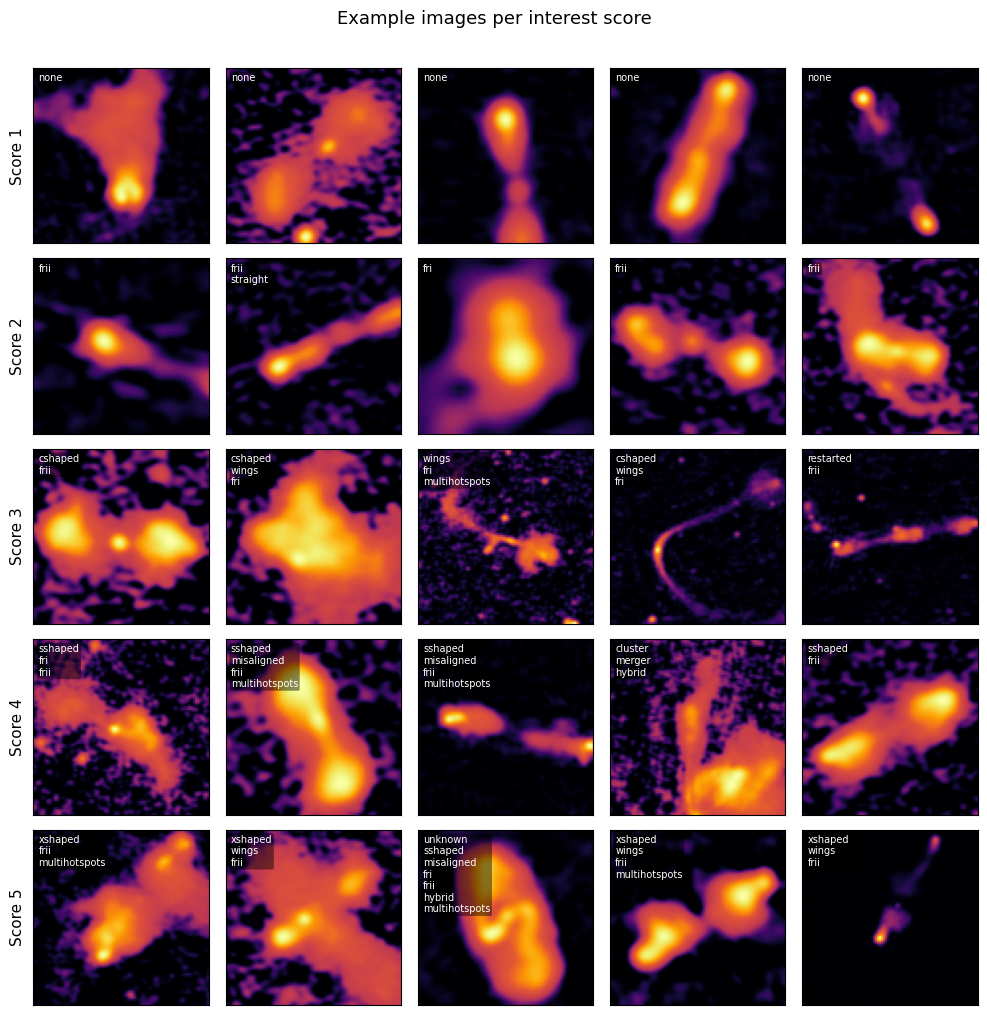

In [18]:

# Show 5 example images for each interest score (1–5)
images_all = np.load("/users/mbredber/p3_SUPLAT/data/preprocessed/lotss/images_filtered.npy")
images = images_all[idx_arr]  # align with current split

ALL_MORPH_COLS = SCORE_5 + SCORE_4 + SCORE_3 + SCORE_2

N_EXAMPLES = 5
scores = [1, 2, 3, 4, 5]
rng = np.random.default_rng(42)

fig, axes = plt.subplots(len(scores), N_EXAMPLES, figsize=(N_EXAMPLES * 2, len(scores) * 2))

for row, score in enumerate(scores):
    idxs = np.where(human_labels == score)[0]
    chosen = rng.choice(idxs, size=min(N_EXAMPLES, len(idxs)), replace=False)
    for col in range(N_EXAMPLES):
        ax = axes[row, col]
        if col < len(chosen):
            img = images[chosen[col]]
            if img.ndim == 3:
                img = img[0]  # take first channel if multi-channel
            ax.imshow(img, cmap='inferno', origin='lower')
            # Class labels: all True morphology columns for this source
            row_data = labels_npy_df.iloc[chosen[col]]
            active = [c for c in ALL_MORPH_COLS if row_data.get(c, False)]
            label_str = "\n".join(active) if active else "none"
            ax.text(0.03, 0.97, label_str, transform=ax.transAxes,
                    fontsize=7, color="white", va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.45, lw=0))
        else:
            ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f"Score {score}", fontsize=11, labelpad=6)

fig.suptitle("Example images per interest score", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Gaussian Process Active Learning Loop

Initialise uniform anomaly scores, seed `INITIAL_STEPS` evenly-spaced sources with score 1, normalise, then run the GP loop. At each iteration the acquisition function identifies the highest-value unlabelled sources; ground-truth labels are revealed and the GP is re-fit. Continues until `N_LABELS_TOTAL` sources have been labelled.

In [ ]:
def run_GP_active_learning(features, labels, input_anomaly_scores, output_dir,
                           steps=10, initial_steps=None, N_labels=100, epsilon=0.5):
    anomaly_scores = input_anomaly_scores.copy()
    anomaly_scores['human_label'] = [-1] * len(anomaly_scores)
    pipeline_active_learning = protege.GaussianProcess(
        features, force_rerun=True, output_dir=output_dir, ei_tradeoff=epsilon)
    if initial_steps is not None:
        anomaly_scores.sort_values('score', ascending=False, inplace=True)
        inds = anomaly_scores[anomaly_scores.human_label == -1].index[:initial_steps]
        anomaly_scores.loc[inds, 'human_label'] = labels.loc[inds, 'human_label']
        features_with_labels = pipeline_active_learning.combine_data_frames(features, anomaly_scores)
        active_output = pipeline_active_learning.run(features_with_labels)
        anomaly_scores['trained_score'] = active_output['trained_score']
        anomaly_scores['acquisition']   = active_output['acquisition']
    else:
        initial_steps = 0
    for i in range(initial_steps // steps, N_labels // steps):
        anomaly_scores.sort_values('acquisition', ascending=False, inplace=True)
        inds = anomaly_scores[anomaly_scores.human_label == -1].index[:steps]
        anomaly_scores.loc[inds, 'human_label'] = labels.loc[inds, 'human_label']
        features_with_labels = pipeline_active_learning.combine_data_frames(features, anomaly_scores)
        active_output = pipeline_active_learning.run(features_with_labels)
        anomaly_scores['trained_score'] = active_output['trained_score']
        anomaly_scores['acquisition']   = active_output['acquisition']
    return anomaly_scores

# Standardise projections so the GP kernel operates on unit-variance features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
projections_scaled = scaler.fit_transform(projections)

features_pca = pd.DataFrame(projections_scaled, index=source_names)
print("Features shape:", features_pca.shape)
print("Feature mean (should be ~0):", projections_scaled.mean(axis=0)[:5])
print("Feature std  (should be ~1):", projections_scaled.std(axis=0)[:5])

In [20]:
# ── Optional: PCA dimensionality reduction before Protege ────────────────────
# Run this cell to reduce the embedding dimension for the GP kernel.
# Skip it to pass the full standardised projections (projections_scaled) instead.
# Either way, features_pca is what the interactive Protege cell below uses.

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)  # keep 95% of variance
projections_pca = pca.fit_transform(projections_scaled)
print(f"PCA: {projections_scaled.shape[1]}d → {projections_pca.shape[1]}d "
      f"({pca.explained_variance_ratio_.sum():.3f} variance retained)")

features_pca = pd.DataFrame(projections_pca, index=source_names)
print("features_pca updated — GP will use PCA-reduced embeddings.")

PCA: 187d → 37d (0.950 variance retained)
features_pca updated — GP will use PCA-reduced embeddings.


In [ ]:
# Seed with human_label values (1–5) for INITIAL_STEPS evenly-spaced sources
# so the GP starts with real signal rather than a degenerate binary 0/1 split.
_n = len(features_pca)
anomaly_scores = pd.DataFrame({'score': np.zeros(_n)}, index=features_pca.index)
seed_positions = np.linspace(0, _n - 1, INITIAL_STEPS, dtype=int)
seed_names = features_pca.index[seed_positions]
anomaly_scores.loc[seed_names, 'score'] = labels_df.loc[seed_names, 'human_label'].values.astype(float)

# Normalise scores with ScoreConverter
score_converter = human_loop_learning.ScoreConverter(force_rerun=True, output_dir=OUTPUT_DIR)
anomaly_scores = score_converter.run(anomaly_scores)

# ── Diagnostic: score distribution after ScoreConverter ──────────────────
print("\n── anomaly_scores after ScoreConverter ──")
print(anomaly_scores.describe())
print("\nscore value_counts (top 10):")
print(anomaly_scores['score'].value_counts().head(10))
n_unique = anomaly_scores['score'].nunique()
print(f"\nUnique score values: {n_unique}")
if n_unique == 1:
    print("WARNING: all scores are identical — GP has no signal to start from!")
# ─────────────────────────────────────────────────────────────────────────────

# Run active learning loop
active_output = run_GP_active_learning(
    features_pca, labels_df, anomaly_scores,
    output_dir=OUTPUT_DIR,
    steps=STEPS_PER_ITER,
    initial_steps=INITIAL_STEPS,
    N_labels=N_LABELS_TOTAL,
    epsilon=EPSILON,
)
print("Active learning complete. Labelled:", (active_output['human_label'] != -1).sum())

### Recall Curve

Rank all sources by the GP's trained score and plot the cumulative count of high-interest sources (human label ≥ 4) found vs. number of sources inspected, compared against a random-ordering baseline.

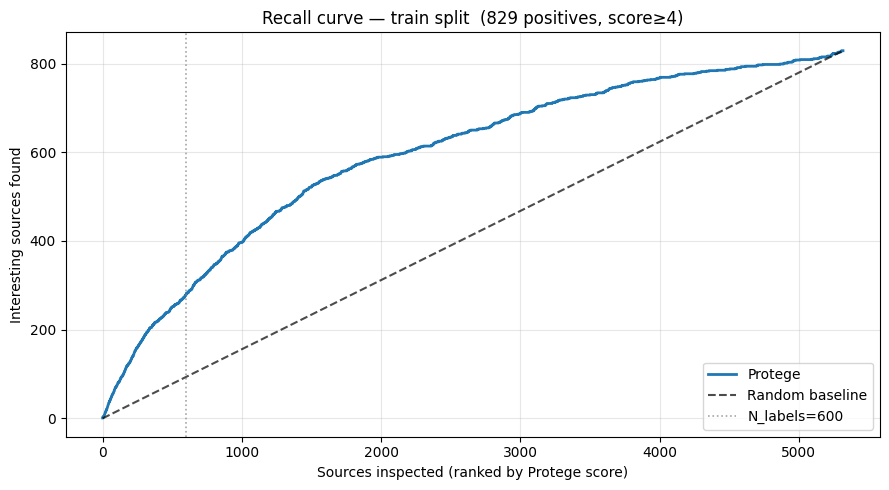

In [22]:
n_pos_total = int(binary_label.sum())
ranked = active_output.sort_values('trained_score', ascending=False)
ranked_binary = np.array([
    1 if binary_label[features_pca.index.get_loc(src)] == 1 else 0
    for src in ranked.index
])

cumulative_found = np.cumsum(ranked_binary)
x_labels = np.arange(1, len(ranked) + 1)

# Random baseline
random_recall = x_labels * (n_pos_total / len(ranked))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_labels, cumulative_found, label='Protege', linewidth=2)
ax.plot(x_labels, random_recall, 'k--', label='Random baseline', linewidth=1.5, alpha=0.7)
ax.axvline(x=N_LABELS_TOTAL, color='grey', linestyle=':', linewidth=1.2, alpha=0.7,
           label=f'N_labels={N_LABELS_TOTAL}')
ax.set_xlabel('Sources inspected (ranked by Protege score)')
ax.set_ylabel('Interesting sources found')
ax.set_title(f'Recall curve — {SPLIT} split  ({n_pos_total} positives, score≥4)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Save Active Learning Scores

Persist the full `active_output` DataFrame (GP scores, acquisition values, revealed labels) to a Parquet file for downstream analysis.

In [23]:
out_path = Path(OUTPUT_DIR) / f"protege_scores_{SPLIT}.parquet"
active_output.to_parquet(out_path)
print(f"Saved: {out_path}")

Saved: /users/mbredber/p3_SUPLAT/outputs/run_no_val_run_f1_sw3_20260521_1641/protege/protege_scores_train.parquet


## Protege Sweep Results

Reads pre-computed Protege scores from `run_protege_sweep.py` output and plots recall curves for all matching runs, grouped by `f` and `sw`.

  ⚠ No protege scores found for run_no_val_run_f0.2_sw1_20260522_1610, skipping.
  loaded run_no_val_run_f0.2_sw3_20260521_1836  (f=0.2, sw=3.0)  eval=3654  pos=589  auc=0.5482
  loaded run_no_val_run_f0.5_sw3_20260521_1904  (f=0.5, sw=3.0)  eval=2059  pos=227  auc=0.5913
  loaded run_no_val_run_f0_sw1_20260521_1517  (f=0.0, sw=1.0)  eval=4717  pos=737  auc=0.5003
  skipping run_no_val_run_f1_sw0.5_20260521_1537  (f=1, no unlabelled eval set)
  skipping run_no_val_run_f1_sw10_20260521_1833  (f=1, no unlabelled eval set)
  skipping run_no_val_run_f1_sw1_20260521_1609  (f=1, no unlabelled eval set)
  skipping run_no_val_run_f1_sw3_20260521_1641  (f=1, no unlabelled eval set)

Loaded 3 Protege runs.


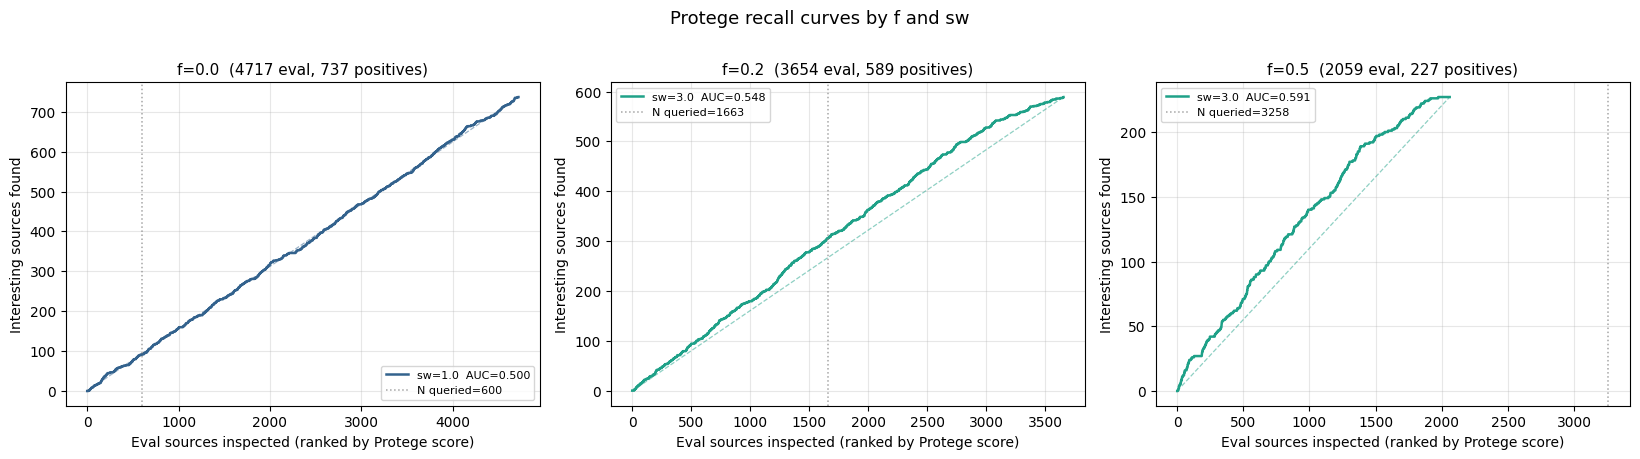


AUC summary (higher = better):
run_name                                           f     sw      AUC    eval    pos
--------------------------------------------------------------------------------
run_no_val_run_f0.5_sw3_20260521_1904           0.50    3.0   0.5913    2059    227
run_no_val_run_f0.2_sw3_20260521_1836           0.20    3.0   0.5482    3654    589
run_no_val_run_f0_sw1_20260521_1517             0.00    1.0   0.5003    4717    737


In [24]:
# ── Protege Sweep Config ──────────────────────────────────────────────────────
PROTEGE_GLOB   = "run_no_val_run_f*_sw*"   # same pattern as nDCG sweep
PROTEGE_SUFFIX = ""                         # output_suffix passed to run_protege_sweep.py
POSITIVE_THRESHOLD = 4                      # human_label >= this counts as positive

LABELS_PATH = LABELS_NPY_PATH              # alias — defined in the Protege Integration Config cell

# ── Load all protege_scores parquet files ────────────────────────────────────
protege_results = []

for rd in sorted(OUTPUTS_ROOT.glob(PROTEGE_GLOB)):
    m = re.search(r'_f([\d.]+)_sw([\d.]+)_', rd.name)
    if not m:
        continue
    f_val  = float(m.group(1))
    sw_val = float(m.group(2))

    if f_val == 1.0:
        print(f"  skipping {rd.name}  (f=1, no unlabelled eval set)")
        continue

    suffix    = f"_{PROTEGE_SUFFIX}" if PROTEGE_SUFFIX else ""
    scores_path  = rd / "protege" / f"protege_scores{suffix}.parquet"
    summary_path = rd / "protege" / f"protege_summary{suffix}.json"

    if not scores_path.exists():
        print(f"  ⚠ No protege scores found for {rd.name}, skipping.")
        continue

    active_output = pd.read_parquet(scores_path)

    # Load summary for eval set metadata
    if summary_path.exists():
        import json
        with open(summary_path) as fh:
            summary = json.load(fh)
        n_eval     = summary["n_eval"]
        n_pos      = summary["n_eval_positives"]
        auc        = summary["auc"]
        n_queried  = summary["n_labelled_seed"] + summary["n_query_additional"]
    else:
        # Fallback: recompute from active_output
        _labels_all   = np.load(LABELS_PATH)
        _lab_idx      = np.load(rd / "data" / "labelled_train_idx.npy")
        _unlab_idx    = np.load(rd / "data" / "unlabelled_train_idx.npy")
        _all_idx      = np.concatenate([_lab_idx, _unlab_idx])
        _csv          = pd.read_csv(CSV_PATH)
        _src_names    = _csv.iloc[_all_idx]["Source_Name"].values
        _lsplit       = _labels_all[_all_idx]
        _ldf          = pd.DataFrame(_lsplit.astype(bool), columns=LABEL_COLS)
        _hl           = np.ones(len(_ldf), dtype=int)
        for _sv, _cols in reversed(TIERS):
            _hl[_ldf[_cols].any(axis=1).values] = _sv
        _labels_df    = pd.DataFrame({"human_label": _hl}, index=_src_names)

        eval_mask  = active_output["human_label"] == -1
        eval_srcs  = active_output[eval_mask].index
        n_eval     = int(eval_mask.sum())
        n_pos      = int((_labels_df.loc[eval_srcs, "human_label"] >= POSITIVE_THRESHOLD).sum())
        n_queried  = int((~eval_mask).sum())
        auc        = None

    protege_results.append(dict(
        name=rd.name, f=f_val, sw=sw_val,
        active_output=active_output,
        n_eval=n_eval, n_pos=n_pos, n_queried=n_queried, auc=auc,
    ))
    print(f"  loaded {rd.name}  (f={f_val}, sw={sw_val})  "
          f"eval={n_eval}  pos={n_pos}  auc={auc:.4f}" if auc else
          f"  loaded {rd.name}  (f={f_val}, sw={sw_val})  eval={n_eval}  pos={n_pos}")

print(f"\nLoaded {len(protege_results)} Protege runs.")

# ── Recall curves — one subplot per f value ──────────────────────────────────
f_vals_p  = sorted(set(r["f"]  for r in protege_results))
sw_vals_p = sorted(set(r["sw"] for r in protege_results))

# Reuse sw_color from nDCG section if available, otherwise build one
try:
    _ = sw_color
except NameError:
    cmap_p   = plt.cm.viridis(np.linspace(0.15, 0.85, len(sw_vals_p)))
    sw_color = {sw: cmap_p[i] for i, sw in enumerate(sw_vals_p)}

ncols = min(len(f_vals_p), 3)
nrows = (len(f_vals_p) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 5.5, nrows * 4.5),
                          sharey=False)
axes = np.array(axes).reshape(nrows, ncols)

for ax_idx, f_val in enumerate(f_vals_p):
    ax = axes[ax_idx // ncols, ax_idx % ncols]
    group = [r for r in protege_results if r["f"] == f_val]

    for r in sorted(group, key=lambda x: x["sw"]):
        ao          = r["active_output"]
        eval_ao     = ao[ao["human_label"] == -1]
        n_eval      = r["n_eval"]
        n_pos       = r["n_pos"]
        ranked_eval = eval_ao.sort_values("trained_score", ascending=False)

        _labels_all  = np.load(LABELS_PATH)
        _lab_idx     = np.load(OUTPUTS_ROOT / r["name"] / "data" / "labelled_train_idx.npy")
        _unlab_idx   = np.load(OUTPUTS_ROOT / r["name"] / "data" / "unlabelled_train_idx.npy")
        _all_idx     = np.concatenate([_lab_idx, _unlab_idx])
        _src_names   = pd.read_csv(CSV_PATH).iloc[_all_idx]["Source_Name"].values
        _ldf         = pd.DataFrame(_labels_all[_all_idx].astype(bool), columns=LABEL_COLS)
        _hl          = np.ones(len(_ldf), dtype=int)
        for _sv, _cols in reversed(TIERS):
            _hl[_ldf[_cols].any(axis=1).values] = _sv
        _true_labels = pd.Series(_hl, index=_src_names)

        binary_eval = (_true_labels.loc[ranked_eval.index] >= POSITIVE_THRESHOLD).astype(int).values
        cumulative  = np.cumsum(binary_eval)
        x           = np.arange(1, n_eval + 1)
        random_line = x * (n_pos / n_eval)

        auc_str = f"  AUC={r['auc']:.3f}" if r["auc"] is not None else ""
        ax.plot(x, cumulative,
                color=sw_color[r["sw"]], linewidth=1.8,
                label=f"sw={r['sw']}{auc_str}")
        ax.plot(x, random_line, color=sw_color[r["sw"]],
                linestyle="--", linewidth=0.9, alpha=0.5)

    ax.axvline(x=r["n_queried"], color="grey", linestyle=":",
               linewidth=1.1, alpha=0.7, label=f"N queried={r['n_queried']}")
    ax.set_title(f"f={f_val}  ({n_eval} eval, {n_pos} positives)", fontsize=11)
    ax.set_xlabel("Eval sources inspected (ranked by Protege score)")
    ax.set_ylabel("Interesting sources found")
    ax.legend(fontsize=8, framealpha=0.8)
    ax.grid(True, alpha=0.3)

for idx in range(len(f_vals_p), nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.suptitle("Protege recall curves by f and sw", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── AUC summary table ────────────────────────────────────────────────────────
if any(r["auc"] is not None for r in protege_results):
    print("\nAUC summary (higher = better):")
    print(f"{'run_name':<45}  {'f':>5}  {'sw':>5}  {'AUC':>7}  {'eval':>6}  {'pos':>5}")
    print("-" * 80)
    for r in sorted(protege_results, key=lambda x: -(x["auc"] or 0)):
        print(f"{r['name']:<45}  {r['f']:>5.2f}  {r['sw']:>5.1f}  "
              f"{r['auc']:>7.4f}  {r['n_eval']:>6}  {r['n_pos']:>5}")

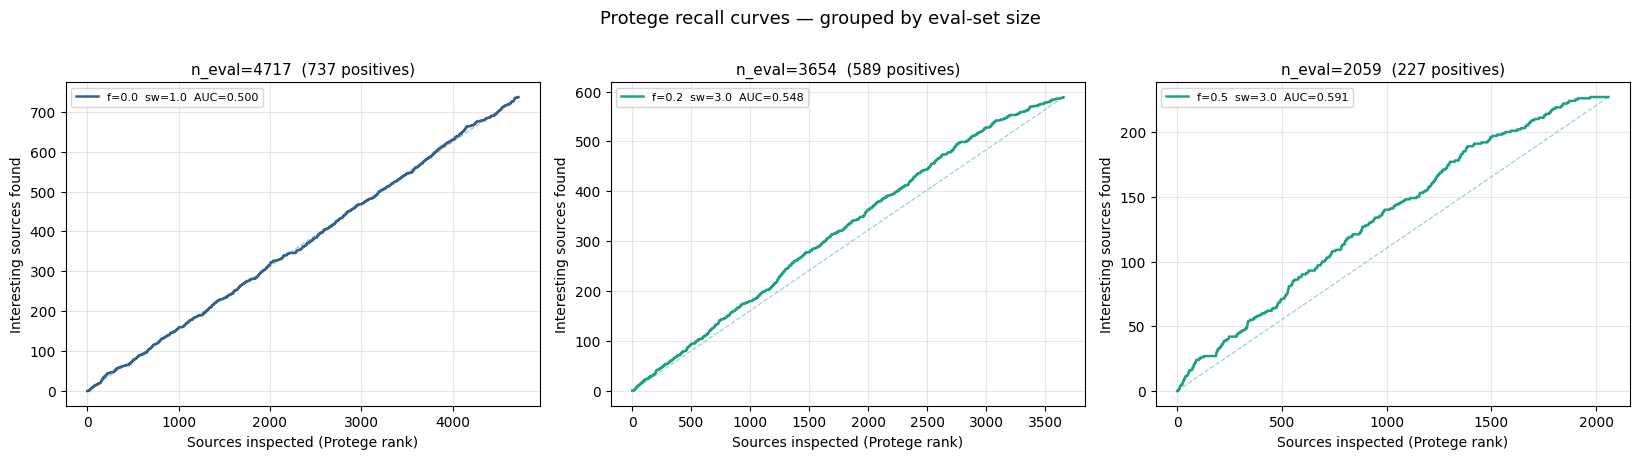

In [25]:
# ── Superfigure: recall curves grouped by eval-set size ──────────────────────
# Each subplot collects all runs whose n_eval is the same (same f + same
# n_query_additional).  Runs are coloured by sw; dashed lines = random baseline.

from collections import defaultdict

# Group by n_eval
groups = defaultdict(list)
for r in protege_results:
    groups[r["n_eval"]].append(r)

eval_sizes = sorted(groups.keys(), reverse=True)   # largest eval first
ncols = min(len(eval_sizes), 3)
nrows = (len(eval_sizes) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 5.5, nrows * 4.5),
                         sharey=False)
axes = np.array(axes).reshape(nrows, ncols)

for ax_idx, n_eval in enumerate(eval_sizes):
    ax    = axes[ax_idx // ncols, ax_idx % ncols]
    group = sorted(groups[n_eval], key=lambda r: r["sw"])

    for r in group:
        ao          = r["active_output"]
        eval_ao     = ao[ao["human_label"] == -1]
        ranked_eval = eval_ao.sort_values("trained_score", ascending=False)

        _labels_all = np.load(LABELS_PATH)
        _lab_idx    = np.load(OUTPUTS_ROOT / r["name"] / "data" / "labelled_train_idx.npy")
        _unlab_idx  = np.load(OUTPUTS_ROOT / r["name"] / "data" / "unlabelled_train_idx.npy")
        _all_idx    = np.concatenate([_lab_idx, _unlab_idx])
        _src_names  = pd.read_csv(CSV_PATH).iloc[_all_idx]["Source_Name"].values
        _ldf        = pd.DataFrame(_labels_all[_all_idx].astype(bool), columns=LABEL_COLS)
        _hl         = np.ones(len(_ldf), dtype=int)
        for _sv, _cols in reversed(TIERS):
            _hl[_ldf[_cols].any(axis=1).values] = _sv
        true_labels = pd.Series(_hl, index=_src_names)

        binary   = (true_labels.loc[ranked_eval.index] >= POSITIVE_THRESHOLD).astype(int).values
        cum      = np.cumsum(binary)
        x        = np.arange(1, n_eval + 1)
        n_pos    = r["n_pos"]
        color    = sw_color[r["sw"]]
        auc_str  = f"  AUC={r['auc']:.3f}" if r["auc"] is not None else ""
        label    = f"f={r['f']}  sw={r['sw']}{auc_str}"

        ax.plot(x, cum, color=color, linewidth=1.8, label=label)
        ax.plot(x, x * (n_pos / n_eval), color=color, linestyle="--",
                linewidth=0.9, alpha=0.45)

    example = group[0]
    ax.set_title(f"n_eval={n_eval}  ({n_pos} positives)", fontsize=11)
    ax.set_xlabel("Sources inspected (Protege rank)")
    ax.set_ylabel("Interesting sources found")
    ax.legend(fontsize=8, framealpha=0.8)
    ax.grid(True, alpha=0.3)

for idx in range(len(eval_sizes), nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.suptitle("Protege recall curves — grouped by eval-set size", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Shared eval set size: 1365  (intersection of 3 runs)
Positives in shared set: 147 / 1365


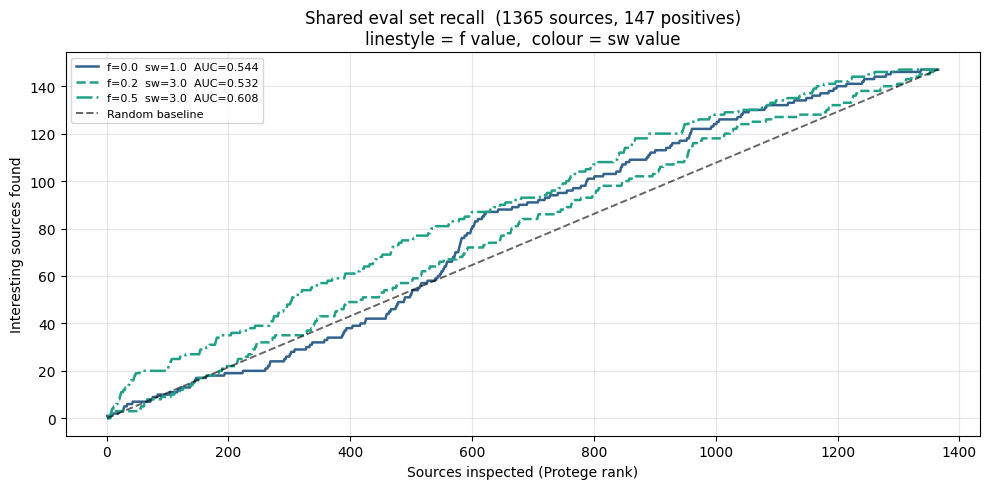

In [26]:
# ── Shared eval set: all non-f=1 runs on the same holdout ────────────────────
# The shared eval set = sources with human_label == -1 in EVERY run, i.e.
# sources that were never queried or seeded by any protege model.
# Each model's trained_score is then used to rank only those shared sources.

# Build set of untouched source names per run
untouched_sets = []
for r in protege_results:
    ao      = r["active_output"]
    untouched = set(ao[ao["human_label"] == -1].index.tolist())
    untouched_sets.append(untouched)

shared_sources = sorted(set.intersection(*untouched_sets))
print(f"Shared eval set size: {len(shared_sources)}  "
      f"(intersection of {len(protege_results)} runs)")

if len(shared_sources) == 0:
    print("No shared sources — cannot plot.")
else:
    # Ground-truth labels for the shared sources
    # Use labels from the first run (all runs cover the same full dataset)
    r0         = protege_results[0]
    _lab_idx   = np.load(OUTPUTS_ROOT / r0["name"] / "data" / "labelled_train_idx.npy")
    _unlab_idx = np.load(OUTPUTS_ROOT / r0["name"] / "data" / "unlabelled_train_idx.npy")
    _all_idx   = np.concatenate([_lab_idx, _unlab_idx])
    _src_names = pd.read_csv(CSV_PATH).iloc[_all_idx]["Source_Name"].values
    _ldf       = pd.DataFrame(np.load(LABELS_PATH)[_all_idx].astype(bool), columns=LABEL_COLS)
    _hl        = np.ones(len(_ldf), dtype=int)
    for _sv, _cols in reversed(TIERS):
        _hl[_ldf[_cols].any(axis=1).values] = _sv
    true_labels_shared = pd.Series(_hl, index=_src_names)

    shared_true = (true_labels_shared.loc[shared_sources] >= POSITIVE_THRESHOLD).astype(int)
    n_shared    = len(shared_sources)
    n_pos_shared = int(shared_true.sum())
    print(f"Positives in shared set: {n_pos_shared} / {n_shared}")

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(1, n_shared + 1)

    # Colour by (f, sw) — reuse sw_color for hue, linestyle for f
    f_vals_present  = sorted(set(r["f"] for r in protege_results))
    linestyles      = ["-", "--", "-.", ":"]
    f_ls            = {f: linestyles[i % len(linestyles)] for i, f in enumerate(f_vals_present)}

    for r in sorted(protege_results, key=lambda r: (r["f"], r["sw"])):
        ao      = r["active_output"]
        scores  = ao.loc[shared_sources, "trained_score"]
        ranked  = scores.sort_values(ascending=False).index
        binary  = shared_true.loc[ranked].values
        cum     = np.cumsum(binary)

        auc_shared = float(np.trapz(cum, x) / (n_shared * n_pos_shared)) if n_pos_shared > 0 else 0.0
        label = f"f={r['f']}  sw={r['sw']}  AUC={auc_shared:.3f}"
        ax.plot(x, cum, color=sw_color[r["sw"]], linestyle=f_ls[r["f"]],
                linewidth=1.8, label=label)

    # Random baseline
    ax.plot(x, x * (n_pos_shared / n_shared), "k--", linewidth=1.4,
            alpha=0.6, label="Random baseline")

    ax.set_xlabel("Sources inspected (Protege rank)")
    ax.set_ylabel("Interesting sources found")
    ax.set_title(f"Shared eval set recall  ({n_shared} sources, {n_pos_shared} positives)\n"
                 f"linestyle = f value,  colour = sw value")
    ax.legend(fontsize=8, framealpha=0.8, loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Interactive Protege Fine-Tuning

Select one run from the sweep results, warm-start the GP from its existing labels,
and continue active learning interactively. The final recall curve shows both the
original sweep result and the interactively fine-tuned result on their respective
evaluation sets (sources never queried by either phase).

In [ ]:
# ── Select which run to fine-tune ────────────────────────────────────────────
FINETUNE_RUN_NAME = "run_no_val_run_f0.5_sw3_20260521_1904"  # edit to pick a run (f≠1)
PROTEGE_SUFFIX    = ""   # must match the suffix used in run_protege_sweep.py

# ── Load the selected run's sweep results ────────────────────────────────────
_ft_run = next((r for r in protege_results if r["name"] == FINETUNE_RUN_NAME), None)
assert _ft_run is not None, (
    f"Run '{FINETUNE_RUN_NAME}' not found in protege_results. "
    f"Available: {[r['name'] for r in protege_results]}"
)

_suffix      = f"_{PROTEGE_SUFFIX}" if PROTEGE_SUFFIX else ""
_scores_path = OUTPUTS_ROOT / FINETUNE_RUN_NAME / "protege" / f"protege_scores{_suffix}.parquet"
_sweep_ao    = pd.read_parquet(_scores_path)

# ── Reconstruct features_pca (mirrors train_protege_list.py logic) ────────────
_data_dir   = OUTPUTS_ROOT / FINETUNE_RUN_NAME / "data"
_lab_idx    = np.load(_data_dir / "labelled_train_idx.npy")
_unlab_idx  = np.load(_data_dir / "unlabelled_train_idx.npy")

_lab_proj        = np.load(_data_dir / "train_projections.npy")
_unlab_proj_path = _data_dir / "unlabelled_train_projections.npy"
if _unlab_proj_path.exists() and len(_lab_idx) > 0 and len(_unlab_idx) > 0:
    _unlab_proj = np.load(_unlab_proj_path)
    _all_proj   = np.concatenate([_lab_proj, _unlab_proj], axis=0)
    _all_idx    = np.concatenate([_lab_idx, _unlab_idx])
elif len(_lab_idx) == 0:   # f=0
    _all_proj = _lab_proj
    _all_idx  = _unlab_idx
else:                       # f=1
    _all_proj = _lab_proj
    _all_idx  = _lab_idx

_csv        = pd.read_csv(CSV_PATH)
_src_names  = _csv.iloc[_all_idx]["Source_Name"].values

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as _PCA

_proj_scaled = StandardScaler().fit_transform(_all_proj)
_pca_model   = _PCA(n_components=0.95, svd_solver="full")
_proj_pca    = _pca_model.fit_transform(_proj_scaled)
ft_features  = pd.DataFrame(_proj_pca, index=_src_names)
print(f"Features: {ft_features.shape}")

# ── Reconstruct true labels ───────────────────────────────────────────────────
_labels_all  = np.load(LABELS_PATH)
_ldf         = pd.DataFrame(_labels_all[_all_idx].astype(bool), columns=LABEL_COLS)
_hl          = np.ones(len(_ldf), dtype=int)
for _sv, _cols in reversed(TIERS):
    _hl[_ldf[_cols].any(axis=1).values] = _sv
ft_true_labels = pd.Series(_hl, index=_src_names)

# ── Record original sweep eval set (human_label == -1 in parquet) ────────────
_sweep_eval_mask = _sweep_ao["human_label"] == -1
_sweep_eval_srcs = set(_sweep_ao[_sweep_eval_mask].index)
n_sweep_eval     = len(_sweep_eval_srcs)
n_sweep_pos      = int((ft_true_labels.loc[list(_sweep_eval_srcs)] >= POSITIVE_THRESHOLD).sum())
print(f"Sweep eval set: {n_sweep_eval} sources, {n_sweep_pos} positives")

# ── Images for interactive display ───────────────────────────────────────────
_images_all    = np.load(IMAGES_PATH)
_ft_images     = _images_all[_all_idx]
_ft_src_to_pos = {src: i for i, src in enumerate(_src_names)}

# ── Initialise GP warm-started from sweep labels ──────────────────────────────
_ft_protege_dir = OUTPUTS_ROOT / FINETUNE_RUN_NAME / "protege" / "interactive"
_ft_protege_dir.mkdir(exist_ok=True)

ft_qs = _sweep_ao.copy()   # has trained_score, acquisition, human_label from sweep

_ft_pipeline = protege.GaussianProcess(
    ft_features, force_rerun=True,
    output_dir=str(_ft_protege_dir), ei_tradeoff=EPSILON)

# Warm-start: run GP once with all sweep-queried labels so acquisition is up to date
_fw = _ft_pipeline.combine_data_frames(ft_features, ft_qs)
_out = _ft_pipeline.run(_fw)
ft_qs["trained_score"] = _out["trained_score"]
ft_qs["acquisition"]   = _out["acquisition"]
print(f"GP warm-started with {int((ft_qs.human_label != -1).sum())} labelled points")

In [28]:
# ── Interactive fine-tuning widget ───────────────────────────────────────────
try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    _install("ipywidgets")
    import ipywidgets as widgets
from IPython.display import display, clear_output

def _ft_get_image(src):
    i = _ft_src_to_pos.get(src)
    if i is None:
        return None
    img = _ft_images[i].astype(float)
    return img[0] if img.ndim == 3 else img

def _ft_show_batch(sources, scores_df):
    n = len(sources)
    ncols = min(n, 5)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 2.8, nrows * 2.8 + 0.4))
    axes = np.array(axes).reshape(nrows, ncols)
    for idx, src in enumerate(sources):
        ax = axes[idx // ncols, idx % ncols]
        img = _ft_get_image(src)
        if img is not None:
            vmax = 0.9 * float(img.max())
            scaled = np.arcsinh(np.clip(img, 0, vmax) / (0.1 * vmax + 1e-8))
            ax.imshow(scaled, cmap="inferno", origin="lower")
        else:
            ax.set_facecolor("#222")
            ax.text(0.5, 0.5, "no image", color="white",
                    ha="center", va="center", transform=ax.transAxes)
        acq = scores_df.loc[src, "acquisition"] if "acquisition" in scores_df.columns else float("nan")
        # Show true label alongside acquisition
        true_score = ft_true_labels.get(src, "?")
        ax.set_title(f"{src[-16:]}\nacq={acq:.3f} | true={true_score}",
                     fontsize=6, pad=2)
        ax.axis("off")
    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].axis("off")
    plt.tight_layout()
    plt.show()

# Widget state
_ft_state     = {"iter": 0}
_ft_inputs    = []
_ft_out_area  = widgets.Output()
_ft_submit    = widgets.Button(description="Submit scores", button_style="success")
_ft_continue  = widgets.Button(description="Next batch →",  button_style="primary")
_ft_stop      = widgets.Button(description="Stop & plot",   button_style="danger")

def _ft_load_batch():
    ft_qs.sort_values("acquisition", ascending=False, inplace=True)
    # Only query from the original sweep eval set — never re-query already labelled sources
    _candidates = ft_qs[
        (ft_qs.human_label == -1) &
        (ft_qs.index.isin(_sweep_eval_srcs))
    ]
    _batch = list(_candidates.index[:STEPS_PER_ITER])
    n_done = int((ft_qs.human_label != -1).sum())
    with _ft_out_area:
        clear_output(wait=True)
        print(f"=== Iteration {_ft_state['iter']} | "
              f"total labelled {n_done} ===")
        _ft_show_batch(_batch, ft_qs)
        print(f"\nEnter scores 1–5 (left→right, top→bottom):")
        for i, src in enumerate(_batch):
            print(f"  [{i}] {src[-22:]}")

    _ft_inputs.clear()
    for src in _batch:
        w = widgets.IntSlider(
            value=2, min=1, max=5, step=1,
            description=f"{src[-18:]}",
            style={"description_width": "200px"},
            layout=widgets.Layout(width="500px"),
        )
        _ft_inputs.append((src, w))

    display(widgets.VBox([w for _, w in _ft_inputs]),
            widgets.HBox([_ft_submit, _ft_stop]))

def _ft_on_submit(b):
    for src, w in _ft_inputs:
        ft_qs.loc[src, "human_label"] = w.value
    _fw = _ft_pipeline.combine_data_frames(ft_features, ft_qs)
    _out = _ft_pipeline.run(_fw)
    ft_qs["trained_score"] = _out["trained_score"]
    ft_qs["acquisition"]   = _out["acquisition"]
    _ft_state["iter"] += 1
    n_done = int((ft_qs.human_label != -1).sum())
    with _ft_out_area:
        print(f"✓ Submitted. Total labelled: {n_done}")
    display(widgets.HBox([_ft_continue, _ft_stop]))

def _ft_on_continue(b):
    _ft_load_batch()

def _ft_on_stop(b):
    _ft_finish()

def _ft_finish():
    # Save updated scores
    _save_path = _ft_protege_dir / "protege_scores_interactive.parquet"
    ft_qs.to_parquet(_save_path)
    print(f"Saved interactive scores to {_save_path}")
    _ft_plot_comparison()

def _ft_plot_comparison():
    # ── Sweep curve (original eval set) ──────────────────────────────────────
    _sw_ranked = _sweep_ao[_sweep_ao.index.isin(_sweep_eval_srcs)].sort_values(
        "trained_score", ascending=False)
    _sw_binary = (ft_true_labels.loc[_sw_ranked.index] >= POSITIVE_THRESHOLD).astype(int).values
    _sw_cum    = np.cumsum(_sw_binary)
    _sw_x      = np.arange(1, len(_sw_ranked) + 1)
    _sw_rand   = _sw_x * (n_sweep_pos / len(_sw_ranked))

    # ── Interactive curve (shrunk eval set: sweep eval \ newly queried) ───────
    _newly_queried = set(ft_qs[
        (ft_qs.human_label != -1) &
        (ft_qs.index.isin(_sweep_eval_srcs))
    ].index)
    _ft_eval_srcs = _sweep_eval_srcs - _newly_queried
    n_ft_eval     = len(_ft_eval_srcs)
    n_ft_pos      = int((ft_true_labels.loc[list(_ft_eval_srcs)] >= POSITIVE_THRESHOLD).sum())

    _ft_ranked = ft_qs[ft_qs.index.isin(_ft_eval_srcs)].sort_values(
        "trained_score", ascending=False)
    _ft_binary = (ft_true_labels.loc[_ft_ranked.index] >= POSITIVE_THRESHOLD).astype(int).values
    _ft_cum    = np.cumsum(_ft_binary)
    _ft_x      = np.arange(1, n_ft_eval + 1)
    _ft_rand   = _ft_x * (n_ft_pos / n_ft_eval)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(_sw_x,  _sw_cum,  color="steelblue",  linewidth=2,
            label=f"Sweep  (eval={n_sweep_eval}, pos={n_sweep_pos})")
    ax.plot(_sw_x,  _sw_rand, color="steelblue",  linewidth=1,
            linestyle="--", alpha=0.5, label="Random (sweep)")
    ax.plot(_ft_x,  _ft_cum,  color="darkorange",  linewidth=2,
            label=f"Interactive  (eval={n_ft_eval}, pos={n_ft_pos})")
    ax.plot(_ft_x,  _ft_rand, color="darkorange",  linewidth=1,
            linestyle="--", alpha=0.5, label="Random (interactive)")
    ax.axvline(x=int((_sweep_ao.human_label != -1).sum()),
               color="grey", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"Sweep N queried")
    ax.axvline(x=int((ft_qs.human_label != -1).sum()),
               color="sienna", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"Interactive N queried")
    ax.set_xlabel("Eval sources inspected (ranked by Protege score)")
    ax.set_ylabel("Interesting sources found")
    ax.set_title(f"Protege recall — {FINETUNE_RUN_NAME}\n"
                 f"Sweep vs interactive fine-tuning")
    ax.legend(fontsize=9, framealpha=0.85)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

_ft_submit.on_click(_ft_on_submit)
_ft_continue.on_click(_ft_on_continue)
_ft_stop.on_click(_ft_on_stop)

display(_ft_out_area)
_ft_load_batch()

Output()

## This interactive session is not really working yet

In [ ]:
try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    _install("ipywidgets")
    import ipywidgets as widgets

from IPython.display import display, clear_output
import time as _time

print("▶ [1/5] Importing widgets … done")

# ── Image lookup from the preloaded npy array ────────────────────────────────
# images_split is already aligned with features_pca.index via idx_arr
_t = _time.time()
images_split = images_all[idx_arr]  # shape (N_split, 89, 89)
print(f"▶ [2/5] Sliced images_all → images_split {images_split.shape}  ({_time.time()-_t:.1f}s)")

src_to_pos = {src: i for i, src in enumerate(source_names)}
print(f"▶ [3/5] Built src_to_pos  ({len(src_to_pos)} entries)")

def _get_image(src):
    i = src_to_pos.get(src)
    if i is None:
        return None
    img = images_split[i].astype(float)
    if img.ndim == 3:
        img = img[0]
    return img

def _asinh_scale(img):
    vmax = 0.9 * float(img.max())
    if vmax <= 0:
        return np.zeros_like(img)
    return np.arcsinh(np.clip(img, 0, vmax) / (0.1 * vmax))

def _show_batch_npy(sources, scores_df):
    n = len(sources)
    ncols = min(n, 5)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.8, nrows * 2.8 + 0.4))
    axes = np.array(axes).reshape(nrows, ncols)
    for idx, src in enumerate(sources):
        ax = axes[idx // ncols, idx % ncols]
        img = _get_image(src)
        if img is not None:
            ax.imshow(_asinh_scale(img), cmap="inferno", origin="lower")
        else:
            ax.set_facecolor("#222")
            ax.text(0.5, 0.5, "no image", color="white",
                    ha="center", va="center", transform=ax.transAxes)
        acq = scores_df.loc[src, "acquisition"] if "acquisition" in scores_df.columns else float("nan")
        ax.set_title(f"{src[-16:]}\nacq={acq:.3f}", fontsize=6, pad=2)
        ax.axis("off")
    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].axis("off")
    plt.tight_layout()
    plt.show()

# ── Widget-based interactive loop ────────────────────────────────────────────
_qs = anomaly_scores.copy()
_qs["human_label"] = -1
print(f"▶ [4/5] Copied anomaly_scores → _qs  ({len(_qs)} rows)")

_t = _time.time()
print(f"▶ [5/5] Initialising GaussianProcess (features_pca shape={features_pca.shape}) …", flush=True)
_pipeline = protege.GaussianProcess(
    features_pca, force_rerun=True, output_dir=OUTPUT_DIR, ei_tradeoff=EPSILON)
print(f"         GaussianProcess ready  ({_time.time()-_t:.1f}s)")

def _get_next_batch(n=STEPS_PER_ITER, seed=False):
    if seed:
        _qs.sort_values("score", ascending=False, inplace=True)
    else:
        _qs.sort_values("acquisition", ascending=False, inplace=True)
    return list(_qs[_qs.human_label == -1].index[:n])

def _run_gp():
    _t = _time.time()
    print(f"  [GP] combine_data_frames …", flush=True)
    fw = _pipeline.combine_data_frames(features_pca, _qs)
    print(f"  [GP] running GP fit  ({_time.time()-_t:.1f}s so far) …", flush=True)
    out = _pipeline.run(fw)
    print(f"  [GP] done  ({_time.time()-_t:.1f}s total)")
    _qs["trained_score"] = out["trained_score"]
    _qs["acquisition"] = out["acquisition"]

# State
_state = {"batch": [], "iter": 0, "done": False}

output_area = widgets.Output()
score_inputs = []
submit_btn = widgets.Button(description="Submit scores", button_style="success")
continue_btn = widgets.Button(description="Next batch →", button_style="primary")
stop_btn = widgets.Button(description="Stop & plot", button_style="danger")

def _load_batch(seed=False):
    _state["batch"] = _get_next_batch(STEPS_PER_ITER, seed=seed)
    n_done = int((_qs.human_label != -1).sum())
    with output_area:
        clear_output(wait=True)
        print(f"=== Iteration {_state['iter']} | labelled {n_done}/{N_LABELS_TOTAL} ===")
        _show_batch_npy(_state["batch"], _qs)
        print(f"\nEnter scores 1–5 for each source (left to right, top to bottom):")
        for i, src in enumerate(_state["batch"]):
            print(f"  [{i}] {src[-20:]}")

    score_inputs.clear()
    for i, src in enumerate(_state["batch"]):
        w = widgets.IntSlider(
            value=2, min=1, max=5, step=1,
            description=f"[{i}] {src[-18:]}",
            style={"description_width": "200px"},
            layout=widgets.Layout(width="500px"),
        )
        score_inputs.append(w)

    box = widgets.VBox(score_inputs)
    controls = widgets.HBox([submit_btn, stop_btn])
    display(box, controls)

def on_submit(b):
    for w, src in zip(score_inputs, _state["batch"]):
        _qs.loc[src, "human_label"] = w.value
    _run_gp()
    _state["iter"] += 1
    n_done = int((_qs.human_label != -1).sum())
    with output_area:
        print(f"✓ Submitted. Total labelled: {n_done}/{N_LABELS_TOTAL}")
    if n_done >= N_LABELS_TOTAL:
        _finish()
    else:
        display(widgets.HBox([continue_btn, stop_btn]))

def on_continue(b):
    _load_batch()

def on_stop(b):
    _finish()

def _finish():
    _state["done"] = True
    global active_output
    active_output = _qs
    n_done = int((_qs.human_label != -1).sum())
    with output_area:
        clear_output(wait=True)
        print(f"Labelling complete. Total labelled: {n_done}")
    _plot_recall()
    out_path = Path(OUTPUT_DIR) / f"protege_scores_interactive_{SPLIT}.parquet"
    active_output.to_parquet(out_path)
    print(f"Saved: {out_path}")

def _plot_recall():
    rated = _qs[_qs.human_label != -1]
    n_pos = int((rated.human_label >= 4).sum())
    ranked = _qs.sort_values("trained_score", ascending=False)
    pos_set = set(rated[rated.human_label >= 4].index)
    cumulative = np.cumsum([1 if s in pos_set else 0 for s in ranked.index])
    x = np.arange(1, len(ranked) + 1)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(x, cumulative, label="Protege (interactive)", linewidth=2)
    ax.plot(x, x * (n_pos / len(ranked)), "k--", label="Random", linewidth=1.5, alpha=0.7)
    ax.set_xlabel("Sources inspected (ranked by Protege score)")
    ax.set_ylabel("Interesting sources found (label ≥ 4)")
    ax.set_title(f"Recall curve — {SPLIT}  ({n_pos} rated positives, {int((_qs.human_label!=-1).sum())} labelled)")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

submit_btn.on_click(on_submit)
continue_btn.on_click(on_continue)
stop_btn.on_click(on_stop)

print("▶ Widgets ready. Loading first batch …", flush=True)
display(output_area)
_t = _time.time()
_load_batch(seed=True)
print(f"▶ First batch loaded  ({_time.time()-_t:.1f}s)")